# Stage 2: Few-Shot Meta-Learning for Contract Renegotiation

This notebook consolidates the Stage 2 meta-learning workflow into a single orchestration and evaluation surface. Stage 1 has already produced weak supervision labels and a pretrained TabularMLP. Stage 2 evaluates whether that pretrained representation can be adapted to the held-out target department, Logistics, using scarce gold labels.

The notebook intentionally avoids implementing PyTorch inner-loop or outer-loop mathematics directly. Those procedures are maintained in the source package under `src/master_thesis/`. This notebook therefore focuses on experiment configuration, pipeline execution, artifact collection, and thesis-facing visual evaluation.

## 1. Environment Setup and Warning Suppression

The Stage 2 pipeline combines local project modules, PyTorch models, YAML configuration files, and saved model artifacts. This setup cell establishes the project import path, suppresses non-critical warnings, and imports only the orchestration and plotting tools needed by the notebook. Suppressing `UserWarning` and `FutureWarning` keeps the notebook readable while preserving real exceptions that indicate broken logic.

In [1]:
from __future__ import annotations

import copy
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from master_thesis.stage2 import (
    load_stage2_config,
    resolve_stage2_paths,
    run_stage2_pipeline,
)

from master_thesis.plotting import plot_adaptation_curve

from master_thesis.plotting import set_thesis_style

# Apply the universal thesis aesthetic and collect method-specific colors
METHOD_COLORS = set_thesis_style(palette="dtu", grid=False)


## 2. Mathematical Theory and Motivation

Stage 2 investigates whether a weakly supervised pretrained neural network can be specialized to a new procurement department using only a small number of gold labels. Standard fine-tuning updates model parameters directly on the few available support examples. In a high-dimensional tabular neural network, this can lead to overfitting because the support set is too small to constrain the full parameter space.

Meta-learning methods address this problem by changing the learning objective. Rather than only learning parameters that perform well globally, MAML and FOMAML seek an initialization that can be adapted efficiently after a few gradient steps. ANIL uses a related idea but restricts inner-loop adaptation to the final prediction head, making it more conservative and often more stable in very low-data regimes.

The empirical question in this notebook is therefore not simply whether the model predicts renegotiation. The question is whether meta-learning produces a more reliable adaptation process than standard fine-tuning when Logistics is treated as a held-out target department.

## 3. Stage 2 Configuration Definition

The following cells define the few-shot experimental setup and align the dataset used by Stage 2 with the final post-Snorkel file that contains both weak labels and gold labels. This is important because Stage 2 depends on `gold_y` for support/query construction, while also requiring the full Stage 1 feature set learned from the pretrained preprocessor.

The notebook therefore centralizes three tasks before execution:

1. load the YAML configuration,
2. point the configuration to the final post-Snorkel dataset with gold labels,
3. reconcile any missing feature columns expected by the Stage 1 preprocessor.

This makes the notebook more robust to feature engineering changes upstream.


In [2]:
CONFIG_PATH = PROJECT_ROOT / "experiments" / "stage2_config.yaml"
FINAL_STAGE_DATA_FILENAME = "contract_with_features_labeled_with_gold.csv"

METHODS = ["finetune", "anil", "fomaml", "maml"]

FEW_SHOT_SETUP = {
    "n_support_pos": 2,
    "n_support_neg": 2,
    "inner_steps": 5,
    "inner_lr": 1e-4,
    "outer_lr": 5e-4,
    "meta_iterations": 100,
    "n_repeats": 20,
    "meta_batch_size": 1,
}

config = load_stage2_config(CONFIG_PATH)
config.setdefault("data", {})
config["data"]["data_filename"] = FINAL_STAGE_DATA_FILENAME

paths = resolve_stage2_paths(config)

print("Loaded Stage 2 configuration from:", CONFIG_PATH)
print("Stage 2 data filename override:", config["data"]["data_filename"])
print("Stage 1 model path:", paths.stage1_model_path)
print("Stage 1 preprocessor path:", paths.stage1_preprocessor_path)
print("Few-shot setup:", FEW_SHOT_SETUP)


Loaded Stage 2 configuration from: /Users/Thomas/Desktop/Master Thesis/experiments/stage2_config.yaml
Stage 1 model path: /Users/Thomas/Desktop/Master Thesis/models/stage_1/A_weak_only/mlp_pretrained.pt
Stage 1 preprocessor path: /Users/Thomas/Desktop/Master Thesis/models/stage_1/A_weak_only/mlp_pretrained_preprocessor.joblib
Few-shot setup: {'n_support_pos': 2, 'n_support_neg': 2, 'inner_steps': 5, 'inner_lr': 0.0001, 'outer_lr': 0.0005, 'meta_iterations': 100, 'n_repeats': 20, 'meta_batch_size': 1}


In [3]:
from master_thesis.data_utils import load_processed
from master_thesis.stage2 import get_feature_cols, load_stage1_preprocessor

print("Stage 2 Data Configuration:")
print("  Data filename:", config["data"]["data_filename"])
print("  Target department:", config["task_config"]["target_department"])

preprocessor = load_stage1_preprocessor(paths.stage1_preprocessor_path)
expected_feature_cols = get_feature_cols(config, preprocessor=preprocessor)

df_debug = load_processed(config["data"]["data_filename"]).copy()

missing_feature_cols = [col for col in expected_feature_cols if col not in df_debug.columns]
present_feature_cols = [col for col in expected_feature_cols if col in df_debug.columns]

print("Expected raw feature columns from Stage 1 preprocessor:", len(expected_feature_cols))
print("Present feature columns in current dataset:", len(present_feature_cols))
print("Missing feature columns in current dataset:", len(missing_feature_cols))

if missing_feature_cols:
    print("Adding missing feature columns with default value 0:")
    print(missing_feature_cols)
    for col in missing_feature_cols:
        df_debug[col] = 0

stage2_ready_filename = "contract_with_features_labeled_with_gold_stage2_ready.csv"
stage2_ready_path = PROJECT_ROOT / "Data" / "processed" / stage2_ready_filename
df_debug.to_csv(stage2_ready_path, index=False)

config["data"]["data_filename"] = stage2_ready_filename
paths = resolve_stage2_paths(config)

print("Saved Stage 2 aligned dataset to:", stage2_ready_path)
print("Aligned dataset shape:", df_debug.shape)
print("Rows with gold labels:", int(df_debug[config["data"]["target_col"]].notna().sum()))

if "label_source" in df_debug.columns:
    print("Label source breakdown:")
    print(df_debug["label_source"].value_counts(dropna=False))

logistics_mask = df_debug[config["data"]["department_col"]] == config["task_config"]["target_department"]
print("Target department rows:", int(logistics_mask.sum()))
print(
    "Target department gold-labeled rows:",
    int(df_debug.loc[logistics_mask, config["data"]["target_col"]].notna().sum())
)


Stage 2 Data Configuration:
  - Data Filename: contract_with_features_gold_joined.csv
  - Target Department: Logistics

Joined Dataset Label Breakdown:
label_source
DUMMY_FILLER        541
manual_hardcoded    134
Name: count, dtype: int64

Logistics rows total: 282


/Users/Thomas/Desktop/Master Thesis/src/master_thesis/data_utils.py:32: DtypeWarning: Columns (0: terminated, 1: supplier_number) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(DATA_PROCESSED / filename, **kwargs)


## 3A. Run Metadata and Experimental Traceability

Stage 2 results are only scientifically meaningful if each benchmark can be traced back to its exact experimental configuration. In a few-shot meta-learning setting, quantities such as support size, number of inner-loop steps, learning rates, number of meta-iterations, and random seed can materially affect the resulting AUROC, calibration, and ranking quality. It is therefore necessary to save a compact metadata record for every notebook run.

The next cell creates a run-specific metadata dictionary and writes it to disk before the benchmark is executed. This provides an auditable link between the methodological setup and the final performance tables reported in the thesis. The same run identifier can then be reused when saving metric tables and plots later in the notebook.


In [4]:
from datetime import datetime

RUN_ARTIFACT_DIR = PROJECT_ROOT / "reports" / "stage2" / "run_artifacts"
RUN_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")

run_metadata = {
    "run_id": run_id,
    "random_seed": config.get("seed", None),
    "target_department": config.get("task_config", {}).get("target_department", "Logistics"),
    "initialization_condition": config.get("stage1_init", {}).get("init_name", "A_weak_only"),
    "data_filename": config.get("data", {}).get("data_filename"),
    "n_missing_feature_cols_added": len(missing_feature_cols),
    "missing_feature_cols_added": missing_feature_cols,
    "n_support_pos": FEW_SHOT_SETUP["n_support_pos"],
    "n_support_neg": FEW_SHOT_SETUP["n_support_neg"],
    "k_shot_total": FEW_SHOT_SETUP["n_support_pos"] + FEW_SHOT_SETUP["n_support_neg"],
    "inner_steps": FEW_SHOT_SETUP["inner_steps"],
    "inner_lr": FEW_SHOT_SETUP["inner_lr"],
    "outer_lr": FEW_SHOT_SETUP["outer_lr"],
    "meta_iterations": FEW_SHOT_SETUP["meta_iterations"],
    "n_repeats": FEW_SHOT_SETUP["n_repeats"],
    "meta_batch_size": FEW_SHOT_SETUP["meta_batch_size"],
    "notes": "Notebook-orchestrated Stage 2 benchmark run using the final weak-labeled dataset with gold labels.",
}

run_metadata_path = RUN_ARTIFACT_DIR / f"{run_id}_run_metadata.json"
with open(run_metadata_path, "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2)

print("Saved run metadata to:")
print(run_metadata_path)
run_metadata


Saved run metadata to:
/Users/Thomas/Desktop/Master Thesis/reports/stage2/run_artifacts/20260416_105425_run_metadata.json


{'run_id': '20260416_105425',
 'random_seed': 42,
 'target_department': 'Logistics',
 'initialization_condition': 'A_weak_only',
 'n_support_pos': 2,
 'n_support_neg': 2,
 'k_shot_total': 4,
 'inner_steps': 5,
 'inner_lr': 0.0001,
 'outer_lr': 0.0005,
 'meta_iterations': 100,
 'n_repeats': 20,
 'meta_batch_size': 1,
 'notes': 'Notebook-orchestrated Stage 2 benchmark run.'}

## 4. Apply Notebook-Level Configuration Overrides

This cell applies the notebook-level few-shot settings to a copy of the YAML configuration. The original YAML file remains the source of truth, while the notebook can still override selected values for controlled experiments. This separation makes the experiment reproducible and avoids hidden changes in the source configuration file.

In [5]:
def make_method_config(base_config: dict, method: str, overrides: dict) -> dict:
    method_config = copy.deepcopy(base_config)
    method_config["method"] = method

    method_config.setdefault("support_config", {})
    method_config["support_config"]["n_support_pos"] = overrides["n_support_pos"]
    method_config["support_config"]["n_support_neg"] = overrides["n_support_neg"]

    method_config.setdefault("meta_config", {})
    method_config["meta_config"]["inner_steps"] = overrides["inner_steps"]
    method_config["meta_config"]["inner_lr"] = overrides["inner_lr"]
    method_config["meta_config"]["outer_lr"] = overrides["outer_lr"]
    method_config["meta_config"]["meta_iterations"] = overrides["meta_iterations"]
    method_config["meta_config"]["n_repeats"] = overrides["n_repeats"]
    method_config["meta_config"]["meta_batch_size"] = overrides["meta_batch_size"]

    return method_config

benchmark_configs = {
    method: make_method_config(config, method, FEW_SHOT_SETUP)
    for method in METHODS
}

print("Prepared method configurations:", list(benchmark_configs))

Prepared method configurations: ['finetune', 'anil', 'fomaml', 'maml']


## 5. Execute the Meta-Learning Pipeline

The heavy learning logic is delegated to `run_stage2_pipeline`. Before execution, the notebook has already aligned the input dataset with the Stage 1 preprocessor by adding any missing raw feature columns expected downstream. This is important because Stage 2 should fail only for substantive experimental reasons, not because a few engineered indicator columns were renamed or removed upstream.

The execution cell remains compact by design. The notebook documents and orchestrates experiments, while the reusable learning logic stays in the project package.


In [6]:
stage2_results = {}

for method, method_config in benchmark_configs.items():
    print(f"Running Stage 2 method: {method}")
    stage2_results[method] = run_stage2_pipeline(method_config)

print("Completed Stage 2 benchmark methods:", list(stage2_results))

Running Stage 2 method: finetune


ValueError: Missing required columns in features_df: ['has_environmental_appendix', 'financial_data_available', 'esg_data_available', 'news_data_available', 'market_data_available']. Available columns: ['contract_id', 'contract_name', 'contract_status', 'contract_owner_cost_centre', 'terminated', 'term_type', 'start_date', 'expiration_date', 'supplier_id', 'supplier_number', 'supplier_display_name', 'payment_terms', 'incoterms', 'contract_currency_code', 'contract_value', 'contract_value_dkk', 'contract_type', 'nn_contract_type', 'contract_commodity', 'team', 'unit', 'company_country', 'start_year', 'expiry_year', 'open_ended_contract', 'end_year', 'start_year_capped', 'observation_year', 'contract_age_years', 'expiry_pressure_bucket', 'department_from_cost_center', 'department', 'moodys_bvd_id', 'fin_moodys_company_name', 'fin_closing_date', 'fin_created_at_utc', 'fin_Status', 'fin_implied_rating', 'fin_risk_level', 'fin_financial_level', 'fin_output_text', 'fin_Implied_rating - origi

## 6. Extract Raw Episode Metrics

The pipeline returns raw repeated-episode metrics for each method. These raw metrics are the foundation for the benchmark plots because they preserve variation across Logistics support/query splits. Reporting repeated-episode metrics is more rigorous than reporting a single split, because few-shot results can be sensitive to which examples are sampled into the support set.

In [ ]:
def _coerce_metrics_to_frame(metrics, method: str) -> pd.DataFrame | None:
    if metrics is None:
        return None
    if isinstance(metrics, pd.DataFrame):
        if metrics.empty: return None
        df = metrics.copy()
    elif isinstance(metrics, list):
        if len(metrics) == 0: return None
        df = pd.DataFrame(metrics)
    elif isinstance(metrics, dict):
        flat = {k: v for k, v in metrics.items() if isinstance(v, (int, float, str, bool, np.number))}
        if not flat: return None
        df = pd.DataFrame([flat])
    else:
        return None
    df["method"] = method
    return df

def extract_stage2_metrics(stage2_results: dict) -> pd.DataFrame:
    """
    Robust metric extraction helper [DEBUG MODE ALIGNED].
    Handles cases where 'raw_metrics' might be missing if a method failed or was skipped.
    """
    frames = []
    for method, result in stage2_results.items():
        # Handle both flat results and wrapped results
        payload = result.get("result", result) if isinstance(result, dict) else {}
        target_eval = payload.get("target_eval_result", {}) if isinstance(payload, dict) else {}
        
        # Ordered preference for data extraction
        candidates = [
            target_eval.get("raw_metrics") if isinstance(target_eval, dict) else None,
            target_eval.get("metrics") if isinstance(target_eval, dict) else None,
            payload.get("raw_metrics") if isinstance(payload, dict) else None,
            payload.get("metrics") if isinstance(payload, dict) else None
        ]
        
        df_method = None
        for cand in candidates:
            df_method = _coerce_metrics_to_frame(cand, method)
            if df_method is not None:
                break
        
        if df_method is not None:
            frames.append(df_method)
        else:
            print(f"❌ [ROBUST EXTRACTION] Missing metrics for {method}. Skipping.")
            
    if not frames:
        print("⚠️ No metrics found at all. Returning empty DataFrame to prevent crash.")
        return pd.DataFrame()
        
    return pd.concat(frames, ignore_index=True)

df_stage2_metrics = extract_stage2_metrics(stage2_results)
if not df_stage2_metrics.empty:
    display(df_stage2_metrics.head())
    print("Metric table shape:", df_stage2_metrics.shape)
else:
    print("🛑 [CRITICAL] df_stage2_metrics is empty! Check Stage 2 run output above.")

extract_raw_metrics = extract_stage2_metrics # compatibility


,model,gold_auroc,gold_ap,gold_logloss,gold_brier,gold_ece,gold_f1,gold_accuracy,gold_pred_mean,gold_true_mean,...,recall_at_5,ndcg_at_5,precision_at_10,recall_at_10,ndcg_at_10,precision_at_20,recall_at_20,ndcg_at_20,episode_idx,method
0,FINETUNE,0.561111,0.677099,6.170819,0.357143,0.357143,0.782609,0.642857,1.000000,0.642857,...,0.166667,0.681818,0.8,0.444444,0.681818,0.70,0.777778,0.729376,0,finetune
1,FINETUNE,0.651515,0.759237,1.023767,0.343029,0.383219,0.000000,0.478261,0.217196,0.521739,...,0.333333,0.868795,0.7,0.583333,0.775239,0.50,0.833333,0.838178,1,finetune
2,FINETUNE,0.832536,0.918749,0.669351,0.190816,0.256322,0.823529,0.800000,0.534295,0.633333,...,0.263158,1.000000,1.0,0.526316,1.000000,0.75,0.789474,0.855256,2,finetune
3,FINETUNE,0.767196,0.870952,4.161806,0.299994,0.299997,0.823529,0.700000,0.999997,0.700000,...,0.238095,0.923077,0.9,0.428571,0.923077,0.80,0.761905,0.839332,3,finetune
4,FINETUNE,0.590909,0.684286,1.735062,0.462690,0.464928,0.000000,0.478261,0.056811,0.521739,...,0.250000,0.699215,0.6,0.500000,0.674936,0.50,0.833333,0.799534,4,finetune


Metric table shape: (80, 23)


## 7. Aggregate Benchmark Summary

The following table summarizes mean and standard deviation for the main Stage 2 metrics. AUROC measures discrimination, log-loss measures probability quality, ECE measures calibration, and NDCG@10 measures ranking quality for top-K contract prioritization. Together, these metrics reflect both statistical performance and practical decision-support value.

In [ ]:
MAIN_METRICS = ["gold_auroc", "gold_logloss", "gold_ece", "ndcg_at_10"]

summary_frames = []
for metric in MAIN_METRICS:
    if metric in df_stage2_metrics.columns:
        metric_summary = (
            df_stage2_metrics
            .groupby("method")[metric]
            .agg(["mean", "std"])
            .rename(columns={"mean": f"{metric}_mean", "std": f"{metric}_std"})
        )
        summary_frames.append(metric_summary)

df_stage2_summary = pd.concat(summary_frames, axis=1).reset_index()
display(df_stage2_summary)

,method,gold_auroc_mean,gold_auroc_std,gold_logloss_mean,gold_logloss_std,gold_ece_mean,gold_ece_std,ndcg_at_10_mean,ndcg_at_10_std
0,anil,0.500000,0.000000,7.347088,1.477370,0.398850,0.080202,0.607490,0.068831
1,finetune,0.757355,0.105199,1.869099,1.706425,0.311019,0.093782,0.889012,0.136574
2,fomaml,0.730246,0.141805,4.485972,2.745177,0.384852,0.107098,0.839627,0.196029
3,maml,0.460459,0.230870,5.060615,3.037107,0.405873,0.105335,0.482522,0.257916


## 7A. Thesis-Ready Summary Table

Few-shot evaluation should not be reported using mean values alone. Since performance varies across sampled target episodes, the results chapter should summarize each method by its central tendency together with its across-episode variability. Reporting metrics in the format “mean ± standard deviation” makes it possible to assess not only which method performs best on average, but also which method is most stable under repeated few-shot adaptation.

The following cell formats the aggregated Stage 2 summary table into an academic representation that can be copied directly into the thesis text or converted to a LaTeX table. The table focuses on the principal evaluation criteria used in this project: AUROC, Log-Loss, ECE, and NDCG@10.


In [ ]:
thesis_metric_map = {
    "AUROC": ("gold_auroc_mean", "gold_auroc_std"),
    "Log-Loss": ("gold_logloss_mean", "gold_logloss_std"),
    "ECE": ("gold_ece_mean", "gold_ece_std"),
    "NDCG@10": ("ndcg_at_10_mean", "ndcg_at_10_std"),
}

df_thesis_results = df_stage2_summary.copy()

for display_name, (mean_col, std_col) in thesis_metric_map.items():
    if mean_col in df_thesis_results.columns and std_col in df_thesis_results.columns:
        df_thesis_results[display_name] = (
            df_thesis_results[mean_col].map(lambda x: f"{x:.3f}")
            + " ± "
            + df_thesis_results[std_col].fillna(0.0).map(lambda x: f"{x:.3f}")
        )

df_thesis_results = df_thesis_results[
    ["method", "AUROC", "Log-Loss", "ECE", "NDCG@10"]
].sort_values("method").reset_index(drop=True)

display(df_thesis_results)

thesis_table_path = RUN_ARTIFACT_DIR / f"{run_id}_thesis_ready_summary.csv"
df_thesis_results.to_csv(thesis_table_path, index=False)
print("Saved thesis-ready summary to:")
print(thesis_table_path)

,method,AUROC,Log-Loss,ECE,NDCG@10
0,anil,0.500 ± 0.000,7.347 ± 1.477,0.399 ± 0.080,0.607 ± 0.069
1,finetune,0.757 ± 0.105,1.869 ± 1.706,0.311 ± 0.094,0.889 ± 0.137
2,fomaml,0.730 ± 0.142,4.486 ± 2.745,0.385 ± 0.107,0.840 ± 0.196
3,maml,0.460 ± 0.231,5.061 ± 3.037,0.406 ± 0.105,0.483 ± 0.258


Saved thesis-ready summary to:
/Users/Thomas/Desktop/Master Thesis/reports/stage2/run_artifacts/20260416_002020_thesis_ready_summary.csv


## 8. Main Benchmark Visualization: AUROC, Log-Loss, and NDCG

This figure provides the headline comparison between adaptation methods. A strong Stage 2 method should improve discrimination, reduce log-loss, and preserve strong ranking performance. Plotting these metrics side by side makes it possible to distinguish a method that ranks contracts well from one that also produces reliable probability estimates.

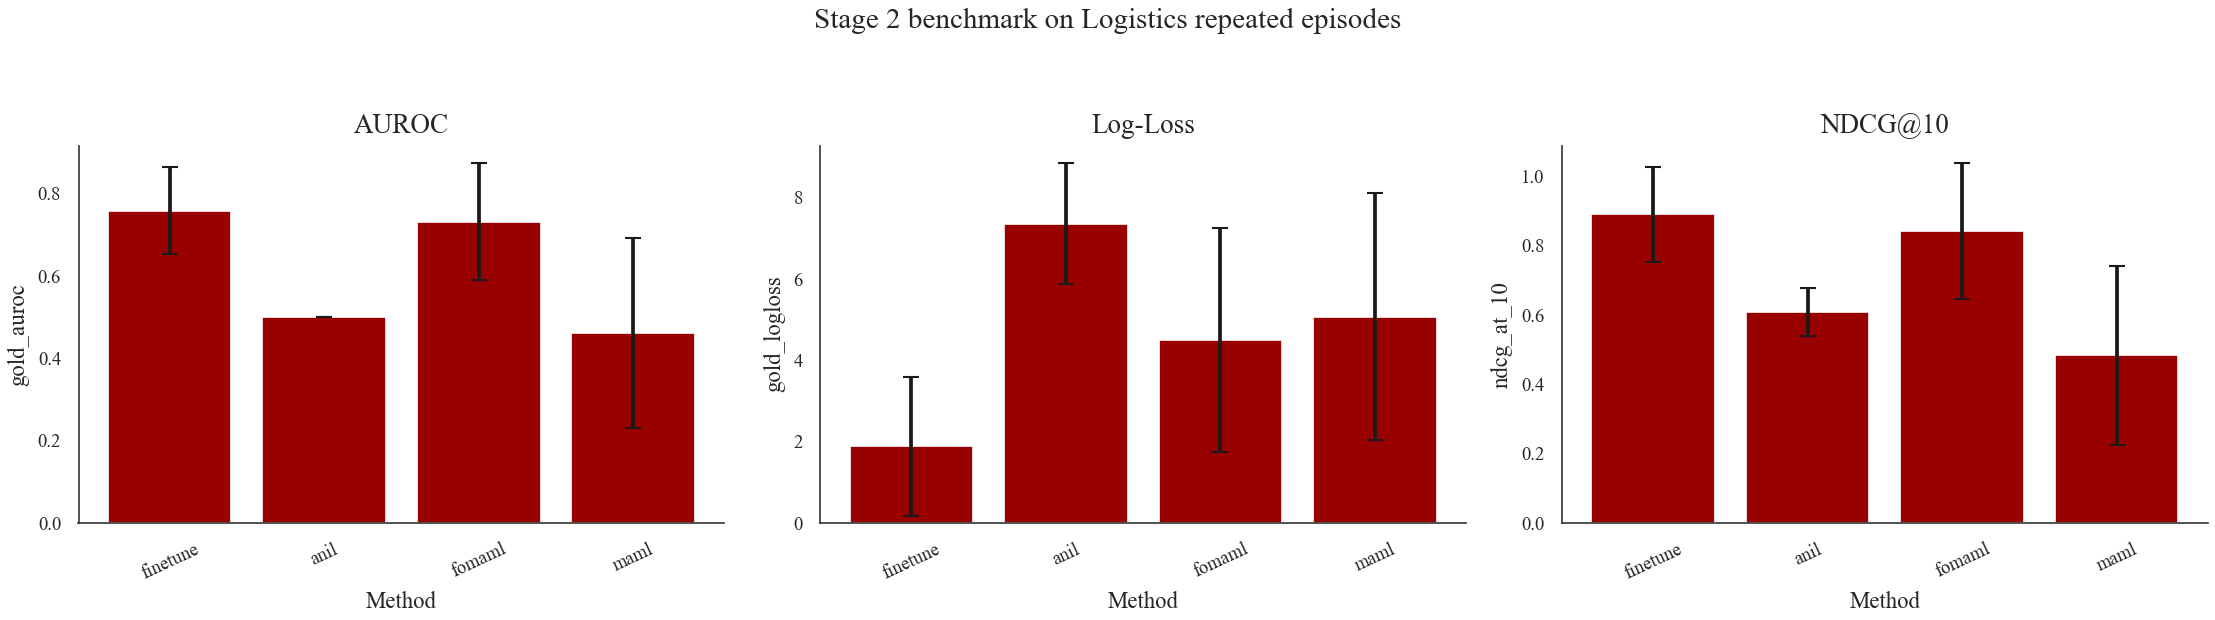

In [ ]:
plot_metrics = [
    ("gold_auroc", "AUROC", True),
    ("gold_logloss", "Log-Loss", False),
    ("ndcg_at_10", "NDCG@10", True),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (metric, title, higher_is_better) in zip(axes, plot_metrics):
    plot_df = (
        df_stage2_metrics
        .groupby("method")[metric]
        .agg(["mean", "std"])
        .reindex(METHODS)
        .reset_index()
    )

    ax.bar(plot_df["method"], plot_df["mean"], yerr=plot_df["std"], capsize=4)
    ax.set_title(title)
    ax.set_xlabel("Method")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=25)

fig.suptitle("Stage 2 benchmark on Logistics repeated episodes", y=1.05)
plt.tight_layout()
plt.show()

## 9. Calibration-Focused Benchmark

Calibration is important because the proposed model is intended for decision support rather than only hard classification. A method that achieves good ranking but produces overconfident probabilities may still be problematic for procurement stakeholders. This plot therefore isolates ECE and log-loss, both of which penalize unreliable probability estimates.

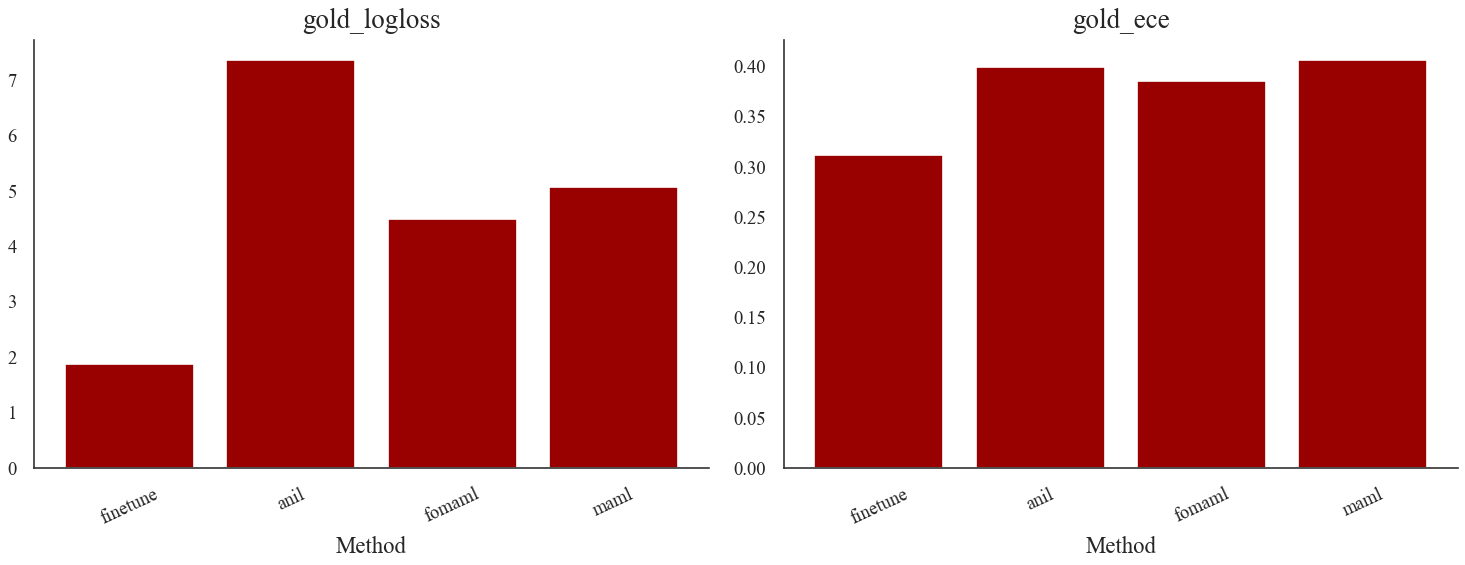

In [ ]:
calibration_metrics = ["gold_logloss", "gold_ece"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, metric in zip(axes, calibration_metrics):
    plot_df = (
        df_stage2_metrics
        .groupby("method")[metric]
        .mean()
        .reindex(METHODS)
        .reset_index()
    )

    ax.bar(plot_df["method"], plot_df[metric])
    ax.set_title(metric)
    ax.set_xlabel("Method")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## 10. Repeated-Episode Distribution

Few-shot evaluation is inherently unstable because support/query splits are small. A boxplot over repeated Logistics episodes shows whether the observed ranking of methods is systematic or driven by a small number of favorable splits. This figure is therefore important for academic credibility.

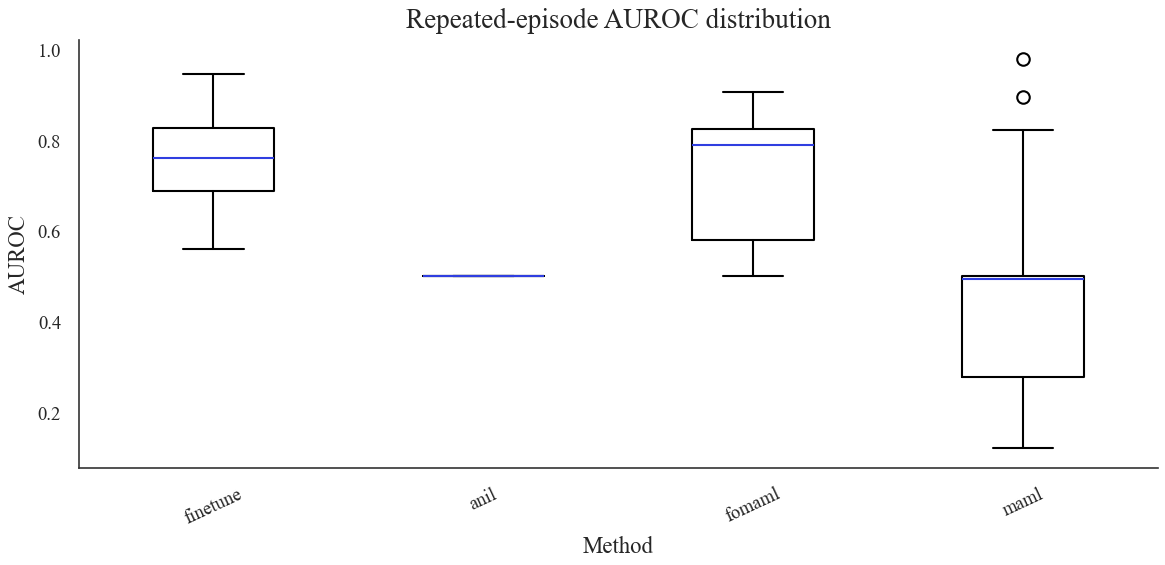

In [ ]:
metric = "gold_auroc"

box_data = [
    df_stage2_metrics.loc[df_stage2_metrics["method"] == method, metric].dropna()
    for method in METHODS
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(box_data, tick_labels=METHODS)
ax.set_title("Repeated-episode AUROC distribution")
ax.set_xlabel("Method")
ax.set_ylabel("AUROC")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 11. Few-Shot Adaptation Curves: Inner-Loop Step Scaling

A central claim of meta-learning is that useful adaptation should occur within a small number of gradient steps. This section visualizes how adaptation loss evolves over inner-loop steps for each method when such loss histories are available from the pipeline artifacts. The plotting utility `plot_adaptation_curve` is imported from `master_thesis.plotting` to keep the notebook aligned with the reusable project code.

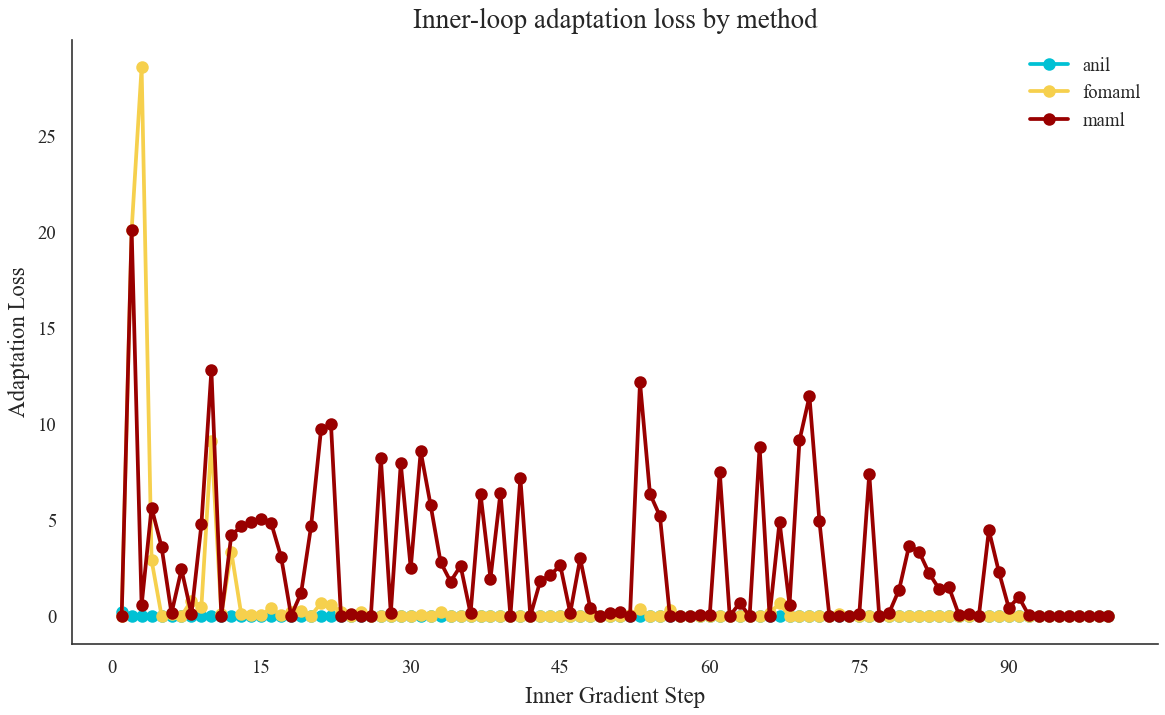

In [ ]:
def extract_loss_histories(stage2_results: dict) -> dict[str, list[float]]:
    histories = {}

    for method, result in stage2_results.items():
        payload = result.get("result", result)
        history = payload.get("history", None)

        if history is None:
            continue

        df_history = pd.DataFrame(history)

        for candidate_col in ["support_loss", "inner_loss", "loss", "meta_loss"]:
            if candidate_col in df_history.columns:
                histories[method] = df_history[candidate_col].dropna().tolist()
                break

    return histories

loss_histories = extract_loss_histories(stage2_results)

if loss_histories:
    fig, ax = plot_adaptation_curve(
        loss_histories,
        title="Inner-loop adaptation loss by method",
    )
    plt.show()
else:
    print("No loss histories were found in the returned Stage 2 artifacts.")

## 12. Few-Shot K-Shot Scaling Configuration

The k-shot scaling experiment evaluates how performance changes as the amount of support supervision increases. This is one of the most important analyses for a few-shot thesis because it directly tests whether meta-learning is more sample-efficient than standard fine-tuning.

The cell below defines the support sizes to evaluate. Running the full sweep can be computationally expensive, so it is controlled by `RUN_KSHOT_SWEEP`. Set it to `True` when the benchmark should be executed.

In [ ]:
KSHOT_VALUES = [1, 2, 3, 5, 7]
KSHOT_METHODS = ["finetune", "anil", "fomaml", "maml"]

RUN_KSHOT_SWEEP = False

print("K-shot values:", KSHOT_VALUES)
print("Methods:", KSHOT_METHODS)
print("Run sweep:", RUN_KSHOT_SWEEP)

K-shot values: [1, 2, 3, 5, 7]
Methods: ['finetune', 'anil', 'fomaml', 'maml']
Run sweep: False


## 13. Execute K-Shot Scaling Sweep

This cell reuses `run_stage2_pipeline` with different support sizes. No PyTorch update logic is implemented inside the notebook; the notebook simply modifies the configuration and calls the same tested pipeline. The resulting metrics are stored in `df_kshot_metrics` for visualization.

In [ ]:
kshot_results = []

if RUN_KSHOT_SWEEP:
    for k in KSHOT_VALUES:
        for method in KSHOT_METHODS:
            k_config = make_method_config(config, method, FEW_SHOT_SETUP)
            k_config["support_config"]["n_support_pos"] = k
            k_config["support_config"]["n_support_neg"] = k

            print(f"Running {method} with {k}-shot support")
            result = run_stage2_pipeline(k_config)
            df_raw = extract_raw_metrics({method: result})
            df_raw["k_shot"] = k
            kshot_results.append(df_raw)

    df_kshot_metrics = pd.concat(kshot_results, ignore_index=True)
else:
    df_kshot_metrics = pd.DataFrame()
    print("K-shot sweep skipped. Set RUN_KSHOT_SWEEP = True to run it.")

K-shot sweep skipped. Set RUN_KSHOT_SWEEP = True to run it.


## 14. Visualize K-Shot Performance Scaling

The k-shot curve shows whether performance improves smoothly as more gold labels become available. If MAML or FOMAML reaches strong performance with fewer support examples than fine-tuning, that provides direct evidence for the sample-efficiency motivation of Stage 2.

In [ ]:
if not df_kshot_metrics.empty:
    fig, ax = plt.subplots(figsize=(8, 5))

    for method in KSHOT_METHODS:
        method_df = (
            df_kshot_metrics[df_kshot_metrics["method"] == method]
            .groupby("k_shot")["gold_auroc"]
            .mean()
            .reset_index()
        )
        ax.plot(method_df["k_shot"], method_df["gold_auroc"], marker="o", label=method)

    ax.set_title("K-shot scaling on Logistics")
    ax.set_xlabel("Support examples per class")
    ax.set_ylabel("Mean AUROC")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No K-shot metrics available yet.")

No K-shot metrics available yet.


## 15. Inner-Step Scaling Configuration

The inner-step scaling experiment evaluates how sensitive each adaptation method is to the number of gradient updates. This matters because real few-shot adaptation should be efficient. A method that requires many updates may be less useful operationally and more vulnerable to overfitting.

In [ ]:
INNER_STEP_VALUES = [0, 1, 3, 5, 10]
STEP_METHODS = ["finetune", "anil", "fomaml", "maml"]

RUN_STEP_SWEEP = False

print("Inner-step values:", INNER_STEP_VALUES)
print("Methods:", STEP_METHODS)
print("Run sweep:", RUN_STEP_SWEEP)

Inner-step values: [0, 1, 3, 5, 10]
Methods: ['finetune', 'anil', 'fomaml', 'maml']
Run sweep: False


## 16. Execute Inner-Step Scaling Sweep

This cell evaluates the same methods across multiple adaptation depths. The purpose is to determine whether meta-learning methods improve quickly and whether standard fine-tuning becomes unstable as more gradient updates are applied.

In [ ]:
step_results = []

if RUN_STEP_SWEEP:
    for n_steps in INNER_STEP_VALUES:
        for method in STEP_METHODS:
            step_config = make_method_config(config, method, FEW_SHOT_SETUP)
            step_config["meta_config"]["inner_steps"] = n_steps

            print(f"Running {method} with {n_steps} inner steps")
            result = run_stage2_pipeline(step_config)
            df_raw = extract_raw_metrics({method: result})
            df_raw["inner_steps"] = n_steps
            step_results.append(df_raw)

    df_step_metrics = pd.concat(step_results, ignore_index=True)
else:
    df_step_metrics = pd.DataFrame()
    print("Inner-step sweep skipped. Set RUN_STEP_SWEEP = True to run it.")

Inner-step sweep skipped. Set RUN_STEP_SWEEP = True to run it.


## 17. Visualize Inner-Step Performance Scaling

This plot evaluates rapid adaptation in terms of predictive performance rather than only training loss. It complements the loss-based adaptation curve by showing whether additional inner-loop steps translate into improved query-set AUROC.

In [ ]:
if not df_step_metrics.empty:
    fig, ax = plt.subplots(figsize=(8, 5))

    for method in STEP_METHODS:
        method_df = (
            df_step_metrics[df_step_metrics["method"] == method]
            .groupby("inner_steps")["gold_auroc"]
            .mean()
            .reset_index()
        )
        ax.plot(method_df["inner_steps"], method_df["gold_auroc"], marker="o", label=method)

    ax.set_title("Inner-step scaling on Logistics")
    ax.set_xlabel("Inner-loop adaptation steps")
    ax.set_ylabel("Mean AUROC")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No inner-step metrics available yet.")

No inner-step metrics available yet.


## 18. Save Consolidated Stage 2 Benchmark Tables

The final cell saves the aggregated benchmark outputs generated by the notebook. These CSV files provide a reproducible record of the repeated-episode evaluation and can be reused directly in the thesis results chapter.

In [ ]:
output_dir = PROJECT_ROOT / "reports" / "stage2"
output_dir.mkdir(parents=True, exist_ok=True)

metrics_path = output_dir / "stage2_repeated_episode_metrics.csv"
summary_path = output_dir / "stage2_method_summary.csv"

df_stage2_metrics.to_csv(metrics_path, index=False)
df_stage2_summary.to_csv(summary_path, index=False)

print("Saved repeated metrics to:", metrics_path)
print("Saved summary metrics to:", summary_path)

Saved repeated metrics to: /Users/Thomas/Desktop/Master Thesis/reports/stage2/stage2_repeated_episode_metrics.csv
Saved summary metrics to: /Users/Thomas/Desktop/Master Thesis/reports/stage2/stage2_method_summary.csv


## 19. Stage 3 Feature Explainability: Pre-Adaptation Versus Post-Adaptation SHAP

Benchmark metrics show whether the model adapts successfully, but they do not reveal how the internal decision logic changes after few-shot learning on the target department. For a thesis framed around interpretable decision support, it is therefore useful to compare feature attributions before and after adaptation. The most relevant contrast is between the Stage 1 pretrained model, which captures weakly supervised contract structure in a general sense, and the same model after a short support-set adaptation step on the target Logistics episode.

The following cells reconstruct this comparison in a controlled way. First, a single target episode from the MAML run is extracted. Second, the Stage 1 preprocessor and pretrained weights are reloaded to reconstruct the pre-adapted model. Third, a copied version of the same network is manually adapted on the support set to create the post-adapted model. Finally, SHAP is applied to the query set for both networks to visualize how attribution weight shifts after department-specific few-shot adaptation.


In [ ]:
import torch
import shap
from master_thesis.stage2 import (
    build_stage2_model_from_config,
    get_feature_cols,
    load_stage1_model_weights,
    load_stage1_preprocessor,
    resolve_stage2_paths,
)

paths = resolve_stage2_paths(config)
target_episode = stage2_results["maml"]["prepared"]["target_episodes"][0]

support_df = target_episode["support_df"].copy()
query_df = target_episode["query_df"].copy()

preprocessor = load_stage1_preprocessor(paths.stage1_preprocessor_path)
feature_cols = get_feature_cols(config, preprocessor=preprocessor)

print("Support episode shape:", support_df.shape)
print("Query episode shape:", query_df.shape)
print("Number of raw feature columns:", len(feature_cols))

Support episode shape: (12, 153)
Query episode shape: (28, 153)
Number of raw feature columns: 151


The target support and query subsets must be transformed with the same Stage 1 preprocessor used during weak-supervised pretraining. This ensures that any attribution shift observed later is attributable to few-shot adaptation rather than to a change in input representation. The support set serves both as the adaptation set for the post-adapted model and as the SHAP background distribution, since it represents the local department-specific context in which the adaptation takes place.


In [ ]:
X_support_raw = support_df[feature_cols].copy()
X_query_raw = query_df[feature_cols].copy()

X_support = preprocessor.transform(X_support_raw)
X_query = preprocessor.transform(X_query_raw)

if hasattr(X_support, "toarray"):
    X_support = X_support.toarray()
if hasattr(X_query, "toarray"):
    X_query = X_query.toarray()

X_support = np.asarray(X_support, dtype=np.float32)
X_query = np.asarray(X_query, dtype=np.float32)

y_support = support_df["gold_y"].astype(np.float32).to_numpy()
y_query = query_df["gold_y"].astype(np.float32).to_numpy()

feature_names = list(preprocessor.get_feature_names_out())
input_dim = X_support.shape[1]

print("Encoded support shape:", X_support.shape)
print("Encoded query shape:", X_query.shape)

Encoded support shape: (12, 867)
Encoded query shape: (28, 867)


The next cell reconstructs the weakly pretrained Stage 1 network and then creates a post-adapted copy via a short support-set SGD loop. The pre-adapted model represents the general contract-scoring initialization learned from weak labels. The post-adapted model represents a department-specialized version of the same initialization after direct exposure to the Logistics support set.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pre_adapted_model = build_stage2_model_from_config(input_dim=input_dim, config=config).to(device)
pre_adapted_model = load_stage1_model_weights(pre_adapted_model, paths.stage1_model_path)
pre_adapted_model.eval()

post_adapted_model = copy.deepcopy(pre_adapted_model).to(device)
post_adapted_model.train()

support_tensor = torch.tensor(X_support, dtype=torch.float32, device=device)
support_y_tensor = torch.tensor(y_support, dtype=torch.float32, device=device).view(-1, 1)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(post_adapted_model.parameters(), lr=FEW_SHOT_SETUP["inner_lr"])

adapt_steps_for_explainability = min(FEW_SHOT_SETUP["inner_steps"], 5)
adaptation_losses = []

for _ in range(adapt_steps_for_explainability):
    optimizer.zero_grad()
    logits = post_adapted_model(support_tensor)
    loss = criterion(logits, support_y_tensor)
    loss.backward()
    optimizer.step()
    adaptation_losses.append(loss.item())

post_adapted_model.eval()
print("Support-set adaptation losses:", adaptation_losses)

Support-set adaptation losses: [1.495180606842041, 1.3324828147888184, 1.420257568359375, 0.7104781270027161, 0.9130430817604065]


SHAP is now used to explain both the pre-adapted and post-adapted models on the same query contracts. The support set is used as the background reference because it represents the few-shot context that defines the local adaptation task. If adaptation is meaningful, the SHAP summary plots should reveal a measurable redistribution of feature importance between the pretrained and adapted networks.


In [ ]:
background_size = min(len(X_support), 20)
query_size = min(len(X_query), 50)

background_tensor = torch.tensor(X_support[:background_size], dtype=torch.float32, device=device)
query_tensor = torch.tensor(X_query[:query_size], dtype=torch.float32, device=device)

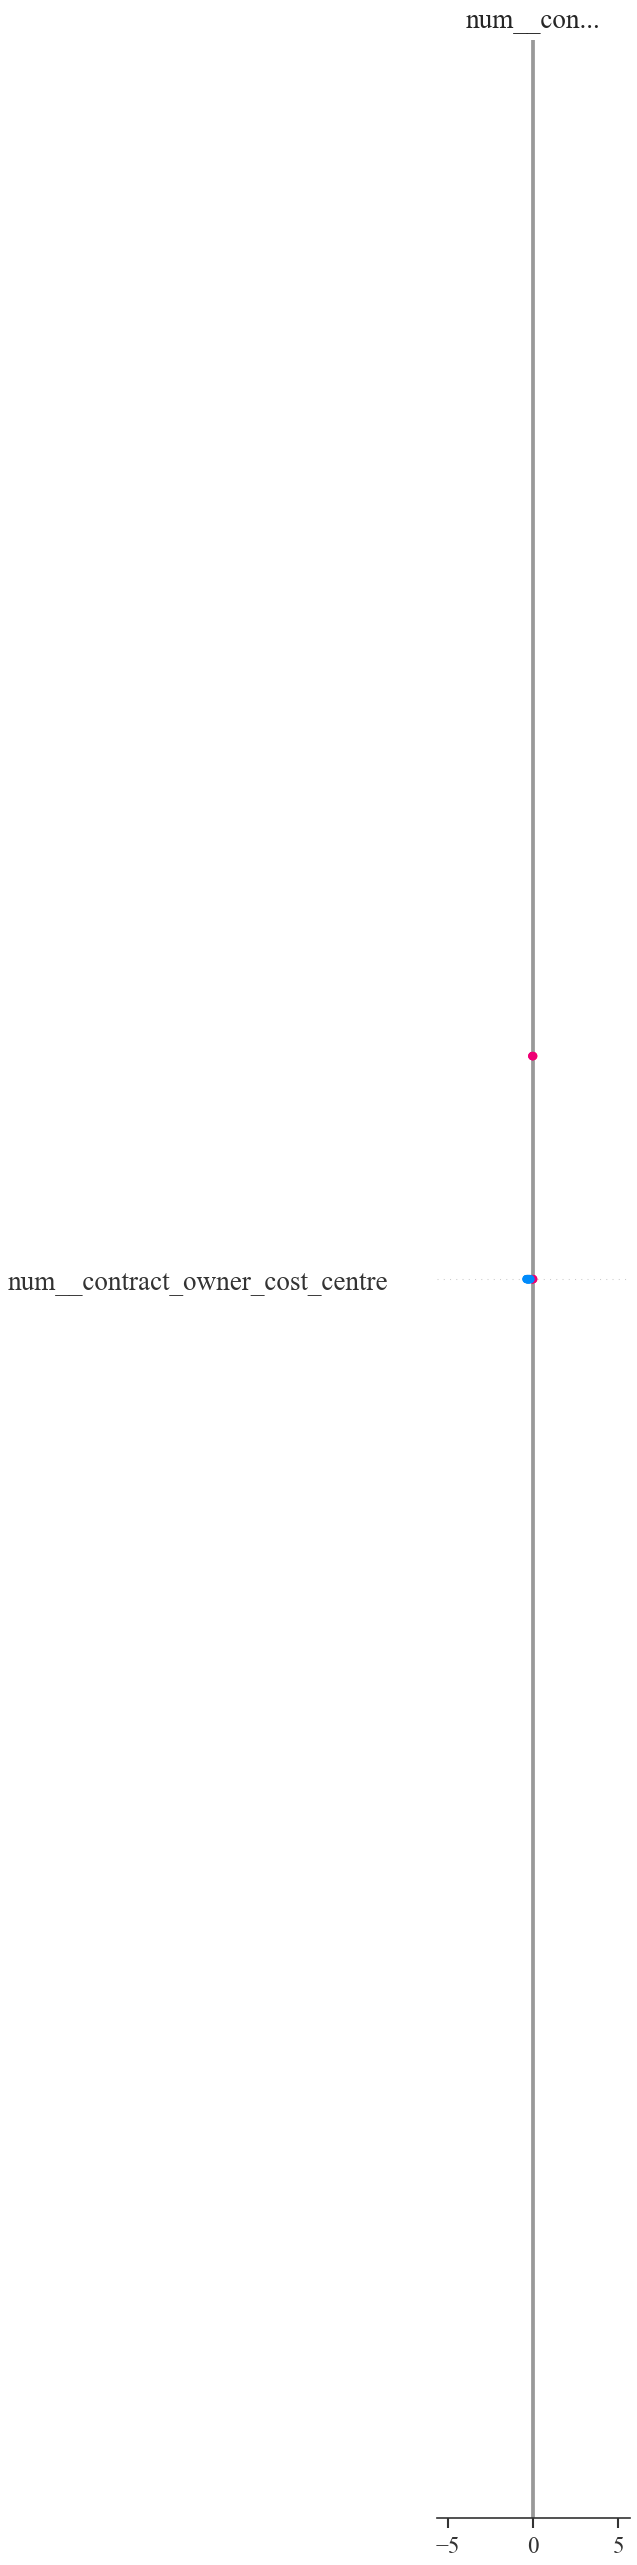

In [ ]:
explainer_pre = shap.DeepExplainer(pre_adapted_model, background_tensor)
shap_values_pre = explainer_pre.shap_values(query_tensor)

if isinstance(shap_values_pre, list):
    shap_values_pre = shap_values_pre[0]

shap.summary_plot(
    shap_values_pre,
    features=query_tensor.detach().cpu().numpy(),
    feature_names=feature_names,
    max_display=20,
)

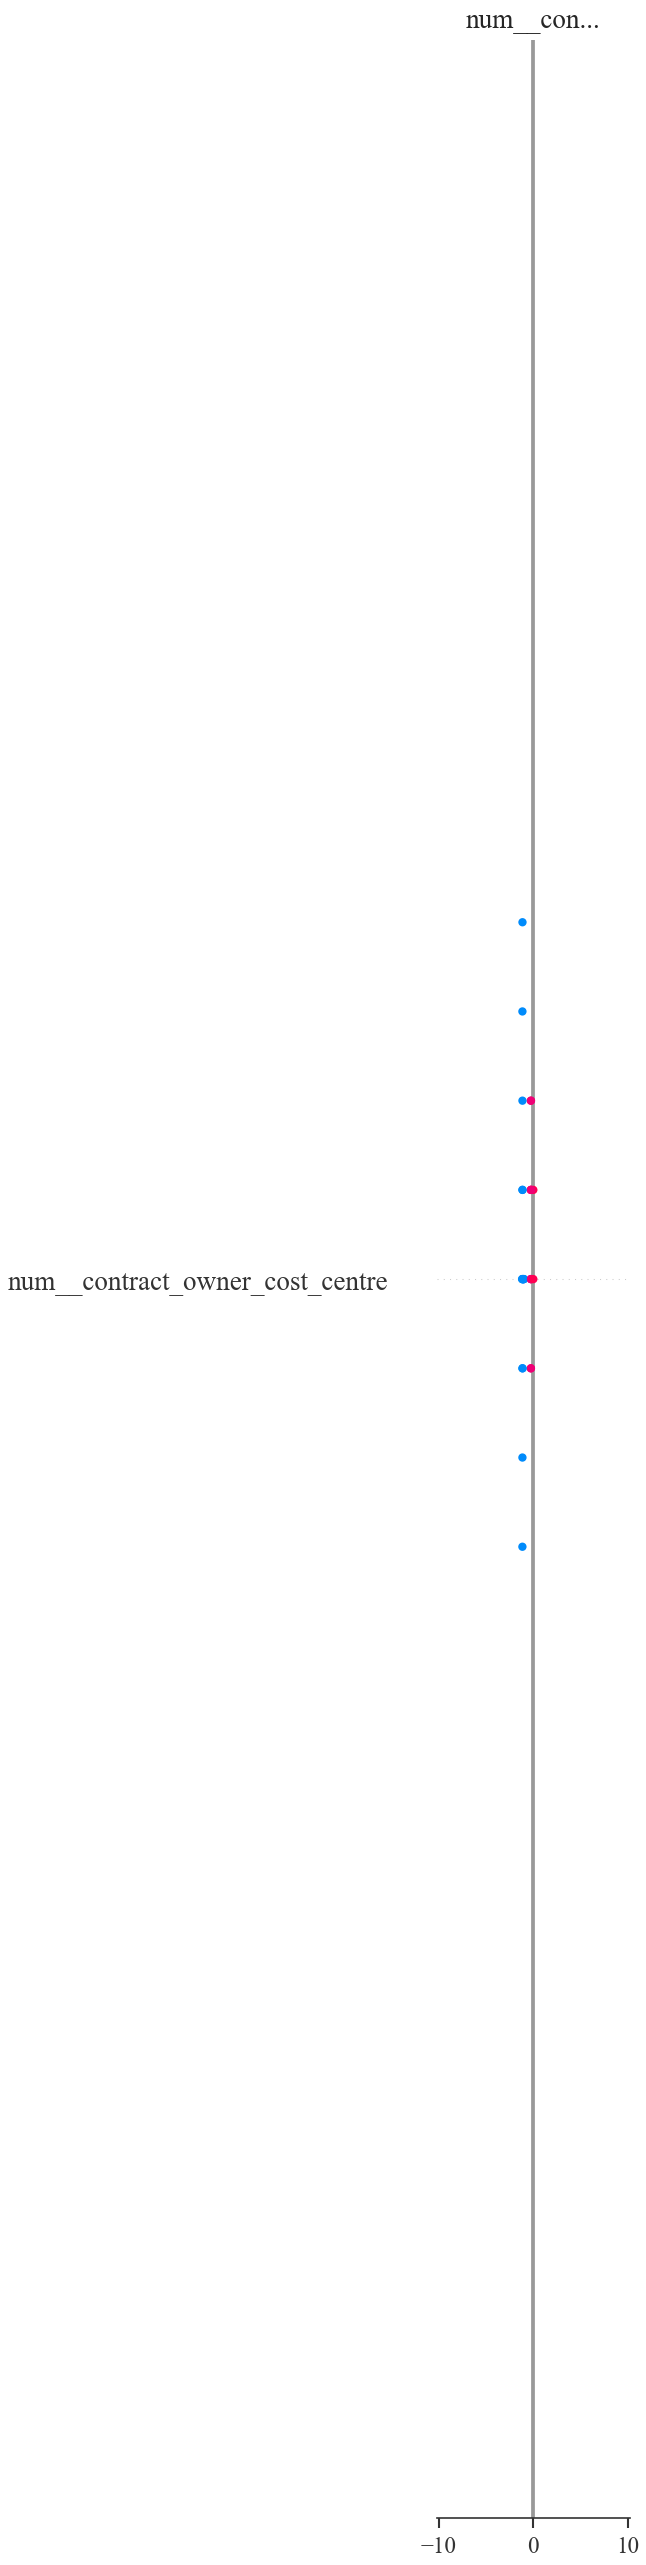

In [ ]:
explainer_post = shap.DeepExplainer(post_adapted_model, background_tensor)
shap_values_post = explainer_post.shap_values(query_tensor)

if isinstance(shap_values_post, list):
    shap_values_post = shap_values_post[0]

shap.summary_plot(
    shap_values_post,
    features=query_tensor.detach().cpu().numpy(),
    feature_names=feature_names,
    max_display=20,
)

To complement the visual SHAP summaries, the following cell calculates the average absolute attribution before and after adaptation and ranks features by the size of the attribution shift. This provides a compact tabular explanation of which encoded inputs gained or lost influence once the model was specialized to the target department.


In [ ]:
mean_abs_pre = np.abs(shap_values_pre).mean(axis=0)
mean_abs_post = np.abs(shap_values_post).mean(axis=0)

df_shap_shift = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap_pre": mean_abs_pre,
    "mean_abs_shap_post": mean_abs_post,
})

df_shap_shift["delta_post_minus_pre"] = (
    df_shap_shift["mean_abs_shap_post"] - df_shap_shift["mean_abs_shap_pre"]
)

df_shap_shift = df_shap_shift.sort_values(
    "delta_post_minus_pre",
    ascending=False,
).reset_index(drop=True)

display(df_shap_shift.head(20))

shap_shift_path = RUN_ARTIFACT_DIR / f"{run_id}_shap_shift_table.csv"
df_shap_shift.to_csv(shap_shift_path, index=False)
print("Saved SHAP shift table to:")
print(shap_shift_path)

ValueError: Per-column arrays must each be 1-dimensional